# Analysing all euro data for the 23/24 season ---PREMIER LEAGUE---

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# EO - REP English premier league
euro_23_24 = pd.read_excel('/home/sirian/Documents/AI_Agents_&_LLMS/Cursor/sirian/data/all-euro-data-2023-2024.xlsx', sheet_name= 'E0')
euro_23_24.head(10)

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,2023-08-11,20:00:00,Burnley,Man City,0,3,A,0,2,...,2.28,1.50,1.95,1.98,1.95,1.97,NaN,NaN,1.92,1.95
1,E0,2023-08-12,12:30:00,Arsenal,Nott'm Forest,2,1,H,2,0,...,2.63,-2.00,1.95,1.98,1.93,1.97,2.01,2.09,1.95,1.92
2,E0,2023-08-12,15:00:00,Bournemouth,West Ham,1,1,D,0,0,...,2.12,0.00,2.02,1.91,2.01,1.92,2.06,1.96,1.96,1.91
3,E0,2023-08-12,15:00:00,Brighton,Luton,4,1,H,1,0,...,2.48,-1.75,2.01,1.92,2.00,1.91,2.14,1.93,2.00,1.86
4,E0,2023-08-12,15:00:00,Everton,Fulham,0,1,A,0,0,...,1.71,-0.25,2.06,1.87,2.04,1.88,2.08,1.99,1.98,1.88
5,E0,2023-08-12,15:00:00,Sheffield United,Crystal Palace,0,1,A,0,0,...,1.53,0.25,2.10,1.83,2.10,1.84,2.12,1.86,2.05,1.83
6,E0,2023-08-12,17:30:00,Newcastle,Aston Villa,5,1,H,2,1,...,2.22,-0.75,1.84,2.09,1.85,2.09,1.87,2.13,1.82,2.06
7,E0,2023-08-13,14:00:00,Brentford,Tottenham,2,2,D,2,2,...,2.15,0.00,1.88,2.02,1.89,2.03,1.95,2.05,1.89,1.98
8,E0,2023-08-13,16:30:00,Chelsea,Liverpool,1,1,D,1,1,...,2.52,0.25,1.98,1.92,2.00,1.93,2.03,2.08,1.91,1.96
9,E0,2023-08-14,20:00:00,Man United,Wolves,1,0,H,0,0,...,2.37,-1.50,1.80,2.00,1.82,2.08,1.88,2.14,1.82,2.05


In [3]:
columns = euro_23_24.columns.tolist()
columns

['Div',
 'Date',
 'Time',
 'HomeTeam',
 'AwayTeam',
 'FTHG',
 'FTAG',
 'FTR',
 'HTHG',
 'HTAG',
 'HTR',
 'Referee',
 'HS',
 'AS',
 'HST',
 'AST',
 'HF',
 'AF',
 'HC',
 'AC',
 'HY',
 'AY',
 'HR',
 'AR',
 'B365H',
 'B365D',
 'B365A',
 'BWH',
 'BWD',
 'BWA',
 'IWH',
 'IWD',
 'IWA',
 'PSH',
 'PSD',
 'PSA',
 'WHH',
 'WHD',
 'WHA',
 'VCH',
 'VCD',
 'VCA',
 'MaxH',
 'MaxD',
 'MaxA',
 'AvgH',
 'AvgD',
 'AvgA',
 'B365>2.5',
 'B365<2.5',
 'P>2.5',
 'P<2.5',
 'Max>2.5',
 'Max<2.5',
 'Avg>2.5',
 'Avg<2.5',
 'AHh',
 'B365AHH',
 'B365AHA',
 'PAHH',
 'PAHA',
 'MaxAHH',
 'MaxAHA',
 'AvgAHH',
 'AvgAHA',
 'B365CH',
 'B365CD',
 'B365CA',
 'BWCH',
 'BWCD',
 'BWCA',
 'IWCH',
 'IWCD',
 'IWCA',
 'PSCH',
 'PSCD',
 'PSCA',
 'WHCH',
 'WHCD',
 'WHCA',
 'VCCH',
 'VCCD',
 'VCCA',
 'MaxCH',
 'MaxCD',
 'MaxCA',
 'AvgCH',
 'AvgCD',
 'AvgCA',
 'B365C>2.5',
 'B365C<2.5',
 'PC>2.5',
 'PC<2.5',
 'MaxC>2.5',
 'MaxC<2.5',
 'AvgC>2.5',
 'AvgC<2.5',
 'AHCh',
 'B365CAHH',
 'B365CAHA',
 'PCAHH',
 'PCAHA',
 'MaxCAHH',
 'MaxCAHA

### Columns explained

The notes from the PDF you shared provide a detailed explanation of the columns used in your football data file. Here's a summary of the key columns:

1. **General Match Data:**
   - `Div`: League Division
   - `Date`: Match Date (dd/mm/yy)
   - `Time`: Match kick-off time
   - `HomeTeam`: Home team name
   - `AwayTeam`: Away team name
   - `FTHG`: Full Time Home Team Goals
   - `FTAG`: Full Time Away Team Goals
   - `FTR`: Full Time Result (H=Home win, D=Draw, A=Away win)
   - `HTHG`: Half Time Home Team Goals
   - `HTAG`: Half Time Away Team Goals
   - `HTR`: Half Time Result (H=Home win, D=Draw, A=Away win)

2. **Match Statistics (if available):**
   - `Attendance`: Crowd attendance
   - `Referee`: Match referee
   - `HS`/`AS`: Home/Away Team Shots
   - `HST`/`AST`: Home/Away Shots on Target
   - `HHW`/`AHW`: Home/Away Hit Woodwork
   - `HC`/`AC`: Home/Away Corners
   - `HF`/`AF`: Home/Away Fouls Committed
   - `HO`/`AO`: Home/Away Offsides
   - `HY`/`AY`: Home/Away Yellow Cards
   - `HR`/`AR`: Home/Away Red Cards

3. **Betting Odds:**
   - `B365H`, `B365D`, `B365A`: Bet365 odds for Home win, Draw, Away win
   - Other bookmaker-specific odds for home, draw, and away outcomes (e.g., Betfair, Ladbrokes, William Hill)
   - `Bb1X2`: Number of bookmakers used to calculate odds averages and maximums
   - `MaxH`, `MaxD`, `MaxA`: Maximum odds for home, draw, and away results
   - `AvgH`, `AvgD`, `AvgA`: Average odds for home, draw, and away results

4. **Asian Handicap and Over/Under Betting:**
   - Columns related to Asian handicap (`BbAH`, `BbAHh`) and over/under goals (e.g., `BbOU`, `BbMx>2.5`).

This data structure will allow you to analyze match results, statistics, and betting odds. What kind of recommendation or analysis would you like to proceed with?

In [4]:
# Check for missing values
print(euro_23_24.isnull().sum())

Div         0
Date        0
Time        0
HomeTeam    0
AwayTeam    0
           ..
PCAHA       0
MaxCAHH     1
MaxCAHA     1
AvgCAHH     0
AvgCAHA     0
Length: 106, dtype: int64


## EDA

### which of these columns has high correlation to FTR (Full time result)

encode Full time result and Half time result

In [5]:
euro_23_24['FTR'] = euro_23_24['FTR'].map({'H': 1, 'D': 0, 'A': 2})
#Encode HTR
euro_23_24['HTR'] = euro_23_24['HTR'].map({'H': 1, 'D': 0, 'A': 2})

euro_23_24

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,2023-08-11,20:00:00,Burnley,Man City,0,3,2,0,2,...,2.28,1.50,1.95,1.98,1.95,1.97,NaN,NaN,1.92,1.95
1,E0,2023-08-12,12:30:00,Arsenal,Nott'm Forest,2,1,1,2,0,...,2.63,-2.00,1.95,1.98,1.93,1.97,2.01,2.09,1.95,1.92
2,E0,2023-08-12,15:00:00,Bournemouth,West Ham,1,1,0,0,0,...,2.12,0.00,2.02,1.91,2.01,1.92,2.06,1.96,1.96,1.91
3,E0,2023-08-12,15:00:00,Brighton,Luton,4,1,1,1,0,...,2.48,-1.75,2.01,1.92,2.00,1.91,2.14,1.93,2.00,1.86
4,E0,2023-08-12,15:00:00,Everton,Fulham,0,1,2,0,0,...,1.71,-0.25,2.06,1.87,2.04,1.88,2.08,1.99,1.98,1.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,E0,2024-05-19,16:00:00,Crystal Palace,Aston Villa,5,0,1,2,0,...,2.78,-0.75,1.73,2.08,1.78,2.16,1.93,2.21,1.81,2.05
376,E0,2024-05-19,16:00:00,Liverpool,Wolves,2,0,1,2,0,...,5.17,-2.75,2.07,1.86,2.04,1.85,2.10,1.89,2.04,1.82
377,E0,2024-05-19,16:00:00,Luton,Fulham,2,4,2,1,2,...,2.69,0.25,2.00,1.93,1.99,1.93,2.02,1.94,1.96,1.91
378,E0,2024-05-19,16:00:00,Man City,West Ham,3,1,1,2,1,...,4.82,-3.00,2.03,1.90,1.99,1.90,2.05,1.99,1.96,1.91


### Home Games Correlation matrix

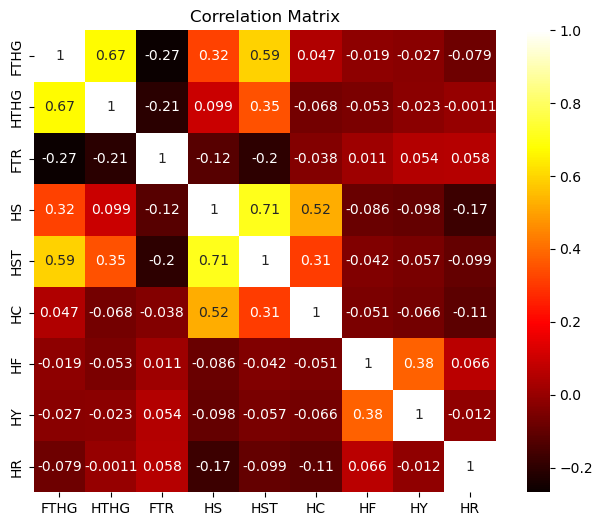

In [6]:
# Select relevant columns for correlation analysis
correlation_columns = ['FTHG', 'HTHG', 'FTR', 'HS', 'HST', 'HC', 'HF','HY', 'HR']

# Calculate the correlation matrix
correlation_matrix = euro_23_24[correlation_columns].corr()
correlation_matrix
# # Extract the correlations with FTR encoded
# ftr_correlations = correlation_matrix['FTR'].sort_values(ascending=False)

# # Print the correlation results
# print(ftr_correlations)

# map correlation matrix to a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='hot', square=True)
plt.title('Correlation Matrix')
plt.show()

The provided image shows a **correlation matrix**, which is a table showing the pairwise correlation coefficients between variables in a dataset. Here's an explanation of the key elements:

#### Key Terms:
- **Correlation Coefficient**: A value between -1 and 1 that indicates the strength and direction of a linear relationship between two variables:
  - **1**: Perfect positive correlation (when one variable increases, the other increases).
  - **-1**: Perfect negative correlation (when one variable increases, the other decreases).
  - **0**: No linear relationship between the variables.

- **Matrix Elements**:
  - The diagonal (from top-left to bottom-right) contains **1s** because each variable is perfectly correlated with itself.
  - Off-diagonal elements represent the correlations between different pairs of variables.

---

#### Variables in the Matrix:
The variable names along the x-axis and y-axis appear to represent features from a dataset. Here’s what the abbreviations might mean based on context (e.g., sports or match statistics):
- **FTHG**: Full-Time Home Goals.
- **HTHG**: Half-Time Home Goals.
- **FTR**: Full-Time Result.
- **HS**: Home Shots.
- **HST**: Home Shots on Target.
- **HC**: Home Corners.
- **HF**: Home Fouls.
- **HY**: Home Yellow Cards.
- **HR**: Home Red Cards.

---

#### Interpretation:
1. **Strong Positive Correlations**:
   - **FTHG (Full-Time Home Goals)** has a high correlation with **HTHG (Half-Time Home Goals)** (0.67), which makes sense since goals at halftime contribute to the final score.
   - **HS (Home Shots)** and **HST (Home Shots on Target)** are highly correlated (0.71), as more shots typically mean more shots on target.

2. **Weak or Negative Correlations**:
   - **FTR (Full-Time Result)** is weakly or negatively correlated with most variables (e.g., -0.27 with **FTHG**, -0.21 with **HTHG**). This might reflect the variability of match outcomes being influenced by many factors.
   - **HY (Home Yellow Cards)** and **HR (Home Red Cards)** are weakly correlated with other variables, likely because disciplinary actions depend on different factors than gameplay statistics.

3. **Interesting Observations**:
   - **HF (Home Fouls)** shows a moderate positive correlation with **HY (Home Yellow Cards)** (0.38), which makes sense since more fouls can lead to more yellow cards.
   - **HC (Home Corners)** shows a modest correlation with **HST (Home Shots on Target)** (0.52), indicating an offensive strategy might generate both corners and shots.

---

#### Color-Coding:
- **Yellow/Light Colors**: Represent strong positive correlations (closer to 1).
- **Dark Red/Black Colors**: Represent weak or negative correlations (closer to 0 or negative values).

This matrix helps identify relationships between features, which can guide further analysis, such as predictive modeling or feature selection.

### Distribution of goals

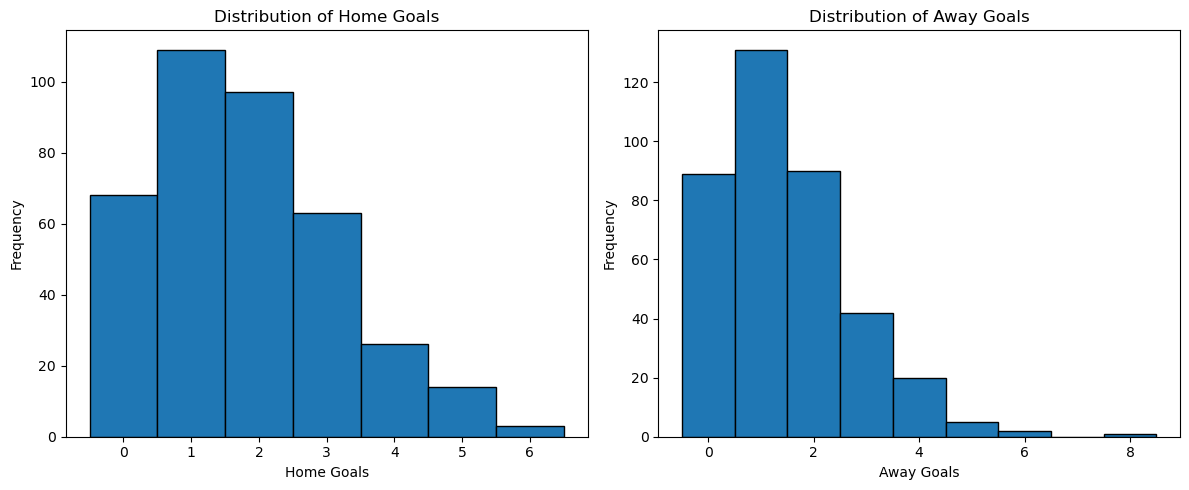

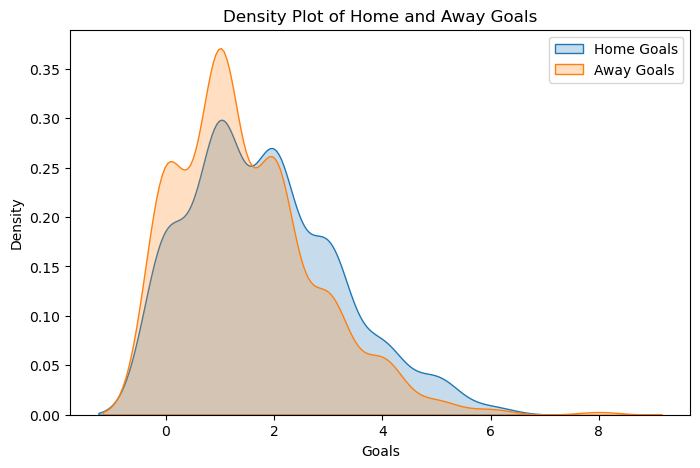

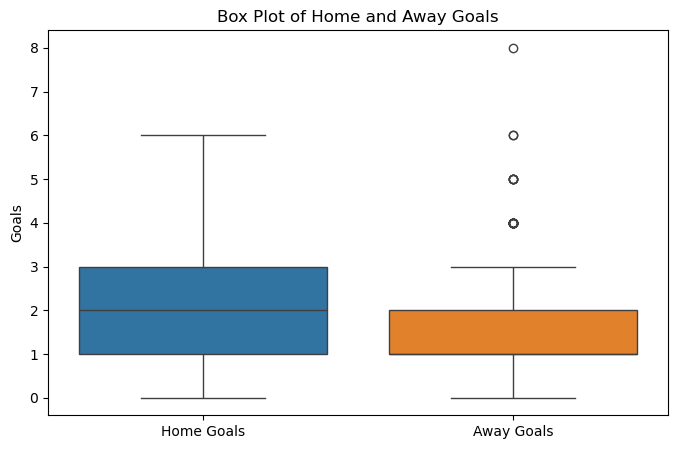

In [7]:
# Visualize the distribution of goals
import seaborn as sns
import matplotlib.pyplot as plt

# --- Histograms ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(euro_23_24['FTHG'], bins=range(0, max(euro_23_24['FTHG'])+2), align='left', edgecolor='black') # Align left for goal counts
plt.title('Distribution of Home Goals')
plt.xlabel('Home Goals')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(euro_23_24['FTAG'], bins=range(0, max(euro_23_24['FTAG'])+2), align='left', edgecolor='black') # Align left for goal counts
plt.title('Distribution of Away Goals')
plt.xlabel('Away Goals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


# --- Density Plots ---
plt.figure(figsize=(8, 5))
sns.kdeplot(euro_23_24['FTHG'], label='Home Goals', fill=True)
sns.kdeplot(euro_23_24['FTAG'], label='Away Goals', fill=True)
plt.title('Density Plot of Home and Away Goals')
plt.xlabel('Goals')
plt.ylabel('Density')
plt.legend()
plt.show()



# --- Box Plots ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=euro_23_24[['FTHG', 'FTAG']])
plt.title('Box Plot of Home and Away Goals')
plt.ylabel('Goals')
plt.xticks(ticks=[0,1], labels=['Home Goals', 'Away Goals']) # Explicit x-axis labels
plt.show()

Teams at home score more goals than when they are playing away matches

## Feature engineering

1.  rolling average of goals scored by home and away teams

In [8]:
euro_23_24['HomeTeamGoalsAVG'] = euro_23_24.groupby('HomeTeam')['FTHG'].rolling(window = 5).mean().reset_index(0, drop = True)
euro_23_24['AwayTeamGoalsAVG'] = euro_23_24.groupby('AwayTeam')['FTAG'].rolling(window = 5).mean().reset_index(0, drop = True)
euro_23_24

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,HomeTeamGoalsAVG,AwayTeamGoalsAVG
0,E0,2023-08-11,20:00:00,Burnley,Man City,0,3,2,0,2,...,1.95,1.98,1.95,1.97,NaN,NaN,1.92,1.95,NaN,NaN
1,E0,2023-08-12,12:30:00,Arsenal,Nott'm Forest,2,1,1,2,0,...,1.95,1.98,1.93,1.97,2.01,2.09,1.95,1.92,NaN,NaN
2,E0,2023-08-12,15:00:00,Bournemouth,West Ham,1,1,0,0,0,...,2.02,1.91,2.01,1.92,2.06,1.96,1.96,1.91,NaN,NaN
3,E0,2023-08-12,15:00:00,Brighton,Luton,4,1,1,1,0,...,2.01,1.92,2.00,1.91,2.14,1.93,2.00,1.86,NaN,NaN
4,E0,2023-08-12,15:00:00,Everton,Fulham,0,1,2,0,0,...,2.06,1.87,2.04,1.88,2.08,1.99,1.98,1.88,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,E0,2024-05-19,16:00:00,Crystal Palace,Aston Villa,5,0,1,2,0,...,1.73,2.08,1.78,2.16,1.93,2.21,1.81,2.05,3.6,0.8
376,E0,2024-05-19,16:00:00,Liverpool,Wolves,2,0,1,2,0,...,2.07,1.86,2.04,1.85,2.10,1.89,2.04,1.82,2.2,0.8
377,E0,2024-05-19,16:00:00,Luton,Fulham,2,4,2,1,2,...,2.00,1.93,1.99,1.93,2.02,1.94,1.96,1.91,1.4,2.0
378,E0,2024-05-19,16:00:00,Man City,West Ham,3,1,1,2,1,...,2.03,1.90,1.99,1.90,2.05,1.99,1.96,1.91,3.4,1.6


2. Calculating the goal difference

In [9]:
team_stats = {}

for index, row in euro_23_24.iterrows():
    home_team = row['HomeTeam']
    away_team = row['AwayTeam']

    # Initialize team stats if not already present
    for team in [home_team, away_team]:
        if team not in team_stats:
            team_stats[team] = {'scored': 0, 'conceded': 0}

    # Update goals scored and conceded
    team_stats[home_team]['scored'] += row['FTHG']
    team_stats[home_team]['conceded'] += row['FTAG']
    team_stats[away_team]['scored'] += row['FTAG']
    team_stats[away_team]['conceded'] += row['FTHG']

# create DataFrame
gd_df = pd.DataFrame.from_dict(team_stats, orient='index')

# Calculate goal difference
gd_df['GoalDifference'] = gd_df['scored'] - gd_df['conceded']

# sort df by goal differrnce in descending order
gd_df.sort_values(by='GoalDifference', ascending=False, inplace=True)
gd_df

,scored,conceded,GoalDifference
Arsenal,91,29,62
Man City,96,34,62
Liverpool,86,41,45
Newcastle,85,62,23
Aston Villa,76,61,15
Chelsea,77,63,14
Tottenham,74,61,13
Man United,57,58,-1
Crystal Palace,57,58,-1
Fulham,55,61,-6


3. Teams Head to Head stats

In [10]:
def extract_head_to_head_result(df):
    """Extracts values from 'FTAW' and 'FTHG' columns to create 'head_to_head_result'.

    Args:
        df: The Pandas DataFrame containing the 'FTAW' and 'FTHG' columns.

    Returns:
        A new DataFrame with the added 'head_to_head_result' column.
        If 'FTAW' or 'FTHG' are not present, it returns the original DataFrame unchanged.
    """

       
    euro_23_24['head_to_head_result'] = euro_23_24.apply(lambda row: f"{row['FTHG']}-{row['FTAG']}", axis=1)
    return euro_23_24


euro_23_24 = extract_head_to_head_result(euro_23_24)
euro_23_24


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,HomeTeamGoalsAVG,AwayTeamGoalsAVG,head_to_head_result
0,E0,2023-08-11,20:00:00,Burnley,Man City,0,3,2,0,2,...,1.98,1.95,1.97,NaN,NaN,1.92,1.95,NaN,NaN,0-3
1,E0,2023-08-12,12:30:00,Arsenal,Nott'm Forest,2,1,1,2,0,...,1.98,1.93,1.97,2.01,2.09,1.95,1.92,NaN,NaN,2-1
2,E0,2023-08-12,15:00:00,Bournemouth,West Ham,1,1,0,0,0,...,1.91,2.01,1.92,2.06,1.96,1.96,1.91,NaN,NaN,1-1
3,E0,2023-08-12,15:00:00,Brighton,Luton,4,1,1,1,0,...,1.92,2.00,1.91,2.14,1.93,2.00,1.86,NaN,NaN,4-1
4,E0,2023-08-12,15:00:00,Everton,Fulham,0,1,2,0,0,...,1.87,2.04,1.88,2.08,1.99,1.98,1.88,NaN,NaN,0-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,E0,2024-05-19,16:00:00,Crystal Palace,Aston Villa,5,0,1,2,0,...,2.08,1.78,2.16,1.93,2.21,1.81,2.05,3.6,0.8,5-0
376,E0,2024-05-19,16:00:00,Liverpool,Wolves,2,0,1,2,0,...,1.86,2.04,1.85,2.10,1.89,2.04,1.82,2.2,0.8,2-0
377,E0,2024-05-19,16:00:00,Luton,Fulham,2,4,2,1,2,...,1.93,1.99,1.93,2.02,1.94,1.96,1.91,1.4,2.0,2-4
378,E0,2024-05-19,16:00:00,Man City,West Ham,3,1,1,2,1,...,1.90,1.99,1.90,2.05,1.99,1.96,1.91,3.4,1.6,3-1


CREATE separate df to store the head to head result.

In [11]:
def create_head_to_head_dataframe(df):
    """Creates a new DataFrame with 'FTHG', 'FTAG', 'head_to_head_result', 'hometeam', and 'awayteam' columns.

    Args:
        df: The original Pandas DataFrame containing at least 'FTHG', 'FTAG', 'hometeam', and 'awayteam' columns.

    Returns:
        A new DataFrame with the specified columns.
        If any of the required columns are missing, it returns None.
        It also adds a 'head_to_head_result' column derived from 'FTHG' and 'FTAG'.
    """

    required_cols = ['HomeTeam', 'AwayTeam','FTHG', 'FTAG', ]
    
    h2h_df = euro_23_24[required_cols].copy() # Create a copy to avoid modifying the original df

    h2h_df['head_to_head_result'] = euro_23_24.apply(
        lambda row: f"{row['FTHG']}-{row['FTAG']}", axis=1
    )

    return h2h_df


h2h_df = create_head_to_head_dataframe(euro_23_24)
h2h_df


,HomeTeam,AwayTeam,FTHG,FTAG,head_to_head_result
0,Burnley,Man City,0,3,0-3
1,Arsenal,Nott'm Forest,2,1,2-1
2,Bournemouth,West Ham,1,1,1-1
3,Brighton,Luton,4,1,4-1
4,Everton,Fulham,0,1,0-1
...,...,...,...,...,...
375,Crystal Palace,Aston Villa,5,0,5-0
376,Liverpool,Wolves,2,0,2-0
377,Luton,Fulham,2,4,2-4
378,Man City,West Ham,3,1,3-1


## Team performance metrics


In [12]:
import pandas as pd
import numpy as np





# Function to calculate team performance metrics
def calculate_team_metrics(df, team_name, num_matches=5):
    # Filter matches involving the team (home or away)
    team_matches = euro_23_24[(euro_23_24['HomeTeam'] == team_name) | (euro_23_24['AwayTeam'] == team_name)]
    
    euro_23_24['FTR'] = euro_23_24['FTR'].map({'H': 1, 'D': 0, 'A': 2})
    #Encode HTR
    euro_23_24['HTR'] = euro_23_24['HTR'].map({'H': 1, 'D': 0, 'A': 2})

    # Get the last 'num_matches' matches
    last_matches = team_matches.tail(num_matches)
    
    # Initialize metrics
    metrics = {
        'Team': team_name,
        'RecentForm': {'Wins': 0, 'Draws': 0, 'Losses': 0},
        'HomePerformance': {'Wins': 0, 'Draws': 0, 'Losses': 0},
        'AwayPerformance': {'Wins': 0, 'Draws': 0, 'Losses': 0},
        'GoalsScored': 0,
        'GoalsConceded': 0,
        'ShotsOnTarget': 0,
        'PossessionPercentage': 0,
        'CleanSheets': 0
    }
    
    for _, match in last_matches.iterrows():
        # Determine if the team is home or away
        is_home = match['HomeTeam'] == team_name
        
        # Full-time result
        if is_home:
            if match['FTR'] == '1':
                metrics['RecentForm']['Wins'] += 1
                metrics['HomePerformance']['Wins'] += 1
            elif match['FTR'] == '0':
                metrics['RecentForm']['Draws'] += 1
                metrics['HomePerformance']['Draws'] += 1
            else:
                metrics['RecentForm']['Losses'] += 1
                metrics['HomePerformance']['Losses'] += 1
        else:
            if match['FTR'] == '2':
                metrics['RecentForm']['Wins'] += 1
                metrics['AwayPerformance']['Wins'] += 1
            elif match['FTR'] == '0':
                metrics['RecentForm']['Draws'] += 1
                metrics['AwayPerformance']['Draws'] += 1
            else:
                metrics['RecentForm']['Losses'] += 1
                metrics['AwayPerformance']['Losses'] += 1
        
        # Goals scored and conceded
        if is_home:
            metrics['GoalsScored'] += match['FTHG']
            metrics['GoalsConceded'] += match['FTAG']
        else:
            metrics['GoalsScored'] += match['FTAG']
            metrics['GoalsConceded'] += match['FTHG']
        
        # Shots on target
        if is_home:
            metrics['ShotsOnTarget'] += match['HST']
        else:
            metrics['ShotsOnTarget'] += match['AST']
        
        # Clean sheets
        if is_home and match['FTAG'] == 0:
            metrics['CleanSheets'] += 1
        elif not is_home and match['FTHG'] == 0:
            metrics['CleanSheets'] += 1
    
    # Calculate averages
    metrics['GoalsScored'] /= num_matches
    metrics['GoalsConceded'] /= num_matches
    metrics['ShotsOnTarget'] /= num_matches
    
    # Possession percentage (assuming possession data is available)
    # If not available, you can skip this or calculate it differently
    # Example: metrics['PossessionPercentage'] = team_matches['Possession'].mean()
    
    return metrics

# Example usage
team_name = 'Manchester United'
metrics = calculate_team_metrics(euro_23_24, team_name, num_matches=5)
print(metrics)

{'Team': 'Manchester United', 'RecentForm': {'Wins': 0, 'Draws': 0, 'Losses': 0}, 'HomePerformance': {'Wins': 0, 'Draws': 0, 'Losses': 0}, 'AwayPerformance': {'Wins': 0, 'Draws': 0, 'Losses': 0}, 'GoalsScored': 0.0, 'GoalsConceded': 0.0, 'ShotsOnTarget': 0.0, 'PossessionPercentage': 0, 'CleanSheets': 0}


In [13]:
# Specify the team you want to analyze
team_name = 'Man City'

# Filter the data for the specified team
team_home = df[df['HomeTeam'] == team_name]
team_away = df[df['AwayTeam'] == team_name]

# Calculate total goals scored by the team
home_goals = team_home['FTHG'].sum()
away_goals = team_away['FTAG'].sum()
total_goals = home_goals + away_goals

# Calculate average goals per match
total_matches = len(team_home) + len(team_away)
average_goals = total_goals / total_matches

# Print the results
print(f"Total goals scored by {team_name}: {total_goals}")
print(f"Average goals per match: {average_goals:.2f}")

# Visualize the goals scored
matches = range(1, total_matches + 1)
goals = team_home['FTHG'].tolist() + team_away['FTAG'].tolist()

plt.figure(figsize=(10, 5))
plt.plot(matches, goals, marker='o', linestyle='-', color='b')
plt.title(f'Goals Scored by {team_name} per Match')
plt.xlabel('Match Number')
plt.ylabel('Goals Scored')
plt.grid(True)
plt.show()

NameError: name 'df' is not defined